<a href="https://colab.research.google.com/github/rogers-mbaluka/DS_Course0_Week1_Module2_DataTypes/blob/main/Copy_of_Module4_Day8Day9_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4 · Days 8 & 9 - Live Build
### Ensemble Models (Random Forests & Boosting) → Support Vector Machines

We pick up exactly where today's Day 5-7 session ended: same Pima diabetes data, same train/test split, and the same open question we never fully answered — the real prevalence in this data is only about 6%, and every model so far has had to fight that imbalance. Tonight, two families of models that handle it differently, and a third model built on a completely different idea than trees.

## Quick reload — same data, same split as

In [ ]:
!pip install faraway

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 4.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                               confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)

from faraway.datasets import pima
data = pima.load()
data['diabetes'] = data['diabetes'].astype(int)
data = data[data['diabetes'] != 2]

features = ['glucose', 'bmi', 'insulin', 'age']
X = data[features]
y = data['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train)}, Test: {len(X_test)}, prevalence: {y.mean():.1%}")


Train: 611, Test: 153, prevalence: 6.2%


Rebuild 's two reference models, so the scoreboard tonight is a direct continuation, not a restart.

In [ ]:
# reference model 1: logistic regression, default
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

# reference model 2: single tuned decision tree, same depth we landed on
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (tuned)"],
    "Accuracy": [accuracy_score(y_test, pred_logreg), accuracy_score(y_test, pred_tree)],
    "Precision": [precision_score(y_test, pred_logreg), precision_score(y_test, pred_tree)],
    "Recall": [recall_score(y_test, pred_logreg), recall_score(y_test, pred_tree)],
    "F1": [f1_score(y_test, pred_logreg), f1_score(y_test, pred_tree)],
})
comparison


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.941176,0.0,0.0,0.0
1,Decision Tree (tuned),0.941176,0.0,0.0,0.0


---
## Step 8 — Random Forests

### 8.1 The idea, before touching data

Yesterday's tuned tree was shallow on purpose, because a deep tree memorizes the training data (Step 7.3's leaf-count explosion). But a shallow tree also has a real weakness: it only asks one or two questions total, so it's making a fairly confident decision off very little evidence, and a slightly different training set could easily grow a noticeably different shallow tree. We actually watched that instability directly , in the fold-variance boxplot.

Here's the fix, in plain language before any code: instead of building one tree and trusting it, build many trees, say 100, each one trained on a slightly different random resample of the same training data (this resampling has a name, **bootstrapping**, sampling with replacement so each tree sees a slightly different subset). Then, to make a prediction, let all 100 trees vote, and go with the majority.

Why does voting help? Each individual tree is a bit noisy, prone to latching onto quirks of whatever random subset it happened to see. But those quirks are different for each tree, and mostly cancel out when you average across all of them. A random forest doesn't fix any one tree's noise, it just makes sure no single tree's noise dominates the final answer. This whole approach, training many models on random resamples and averaging their votes, is called **bagging** (bootstrap aggregating), and a random forest is bagging applied specifically to decision trees, with one more trick: at each split, every tree is only allowed to consider a random subset of the features, not all of them, which forces the trees to actually disagree with each other instead of all discovering the same one strong split (glucose) every time.

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

pred_ref = rf_model.predict(X_test)

accuracy_score(y_test, pred_ref)

0.9411764705882353

### 8.2 Does voting help with the rare class specifically?

Look at that recall number against the single tuned tree's row in the scoreboard above. This is the real test tonight, not "is the forest more accurate," but "does averaging many trees help catch more of the rare diabetic cases, or does it just average toward the same majority-class habit every individual model has had all day?" Read the numbers, don't assume.

In [ ]:
rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

pred_ref_balanced = rf_balanced.predict(X_test)

accuracy_score(y_test, pred_ref_balanced)

0.9411764705882353

### 8.3 A benefit no single tree gives you: feature importance

Because a random forest is built from 100 trees, each splitting on a random subset of features, we can count how often, and how usefully, each feature got used across all of them. That gives a ranked answer to "which features actually mattered," averaged over 100 independent opinions instead of trusting one tree's specific split choices.

In [ ]:
# Step8b — add both forests to the scoreboard
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values()
importance



,0
insulin,0.174884
age,0.216673
glucose,0.303248
bmi,0.305196


---
## Step 8 (continued) — Boosting

### 8.4 A completely different way to combine trees

Bagging builds 100 trees **independently and in parallel**, each one unaware the others exist, then averages their votes at the end. Boosting builds trees **one at a time, in sequence**, and each new tree is deliberately trained to fix the mistakes the trees before it made.

Here's the storyline: tree 1 makes its best attempt at the whole problem, and gets some patients wrong. Tree 2 doesn't start from scratch, it's built specifically to pay extra attention to the patients tree 1 got wrong. Tree 3 does the same relative to the combined mistakes of trees 1 and 2. Keep repeating, and each new tree is a small, targeted correction to the current combined model's weak spots, not a fresh independent guess.

That difference matters for exactly the problem we've been chasing all day: a model that's been getting the rare diabetic cases wrong should, under boosting, start getting extra corrective attention on exactly those cases in the next round, whether or not we manually balance the classes.

In [ ]:
# Step8c
bst_model = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)
bst_model.fit(X_train, y_train)

pred_bst_model = bst_model.predict(X_test)

accuracy_score(y_test, pred_bst_model)



0.934640522875817

In [ ]:
precision_score(y_test, pred_bst_model)

0.0

### 8.5 The two hyperparameters that matter most, and why

`n_estimators` is how many trees get added in sequence. `learning_rate` controls how much each new tree is allowed to correct, a small learning rate means each tree only nudges the model slightly, so you need more trees to reach a good fit, but the result tends to generalize better. A large learning rate lets each tree make big corrections fast, but risks overcorrecting and overfitting, the exact same overfitting story from Step 7, just reached a different way. In practice you tune these two together, more trees needs a smaller learning rate to stay stable, exactly the kind of joint search `GridSearchCV` from  was built for.

In [ ]:
# a quick sweep to make the tradeoff visible, not just described



### 8.6 Bagging vs. boosting, side by side

| | Bagging (Random Forest) | Boosting (Gradient Boosting) |
|---|---|---|
| Trees built | independently, in parallel | sequentially, each fixing the last |
| Main goal | reduce variance (instability between trees) | reduce bias (systematic mistakes) |
| Overfitting risk | low, more trees rarely hurts | real, too many rounds or too high a learning rate can overfit |
| Speed to train | fast, trees don't depend on each other | slower, must be built in order |

Add boosting to the running scoreboard.

In [ ]:
# CodeGrade step8d



---
## Step 9 — Support Vector Machines

### 9.1 Forget diabetes for a second — the simplest possible picture

Imagine just two features, plotted as dots on a page, two colors of dots, and you need to draw one straight line that separates the colors. There are usually many lines that would work. A support vector machine picks a very specific one: the line that leaves the **widest possible empty gap** on both sides before hitting a dot of either color. That gap is called the **margin**, and the SVM's whole job is to maximize it.

Why does the widest gap matter, rather than just any line that separates the colors? A line that barely squeezes between the two groups is fragile, a new dot only slightly different from the training data can easily land on the wrong side. A line with a wide margin on both sides has room to be right about new dots too, not just the ones it was trained on. Wider margin, more confident generalization.

The **support vectors** are the specific dots closest to that dividing line, the ones actually touching the edge of the margin. They're called that because they are the only points that matter for where the line goes, every other dot could move around freely without changing the boundary at all, only the support vectors are load-bearing.

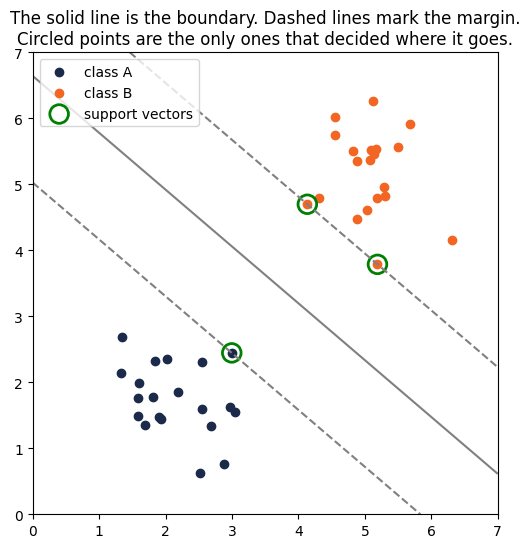

In [ ]:
# a simple, self-contained 2-feature picture before touching the real diabetes model
from sklearn.svm import SVC as SVCDemo

rng = np.random.RandomState(1)
demo_a = rng.normal(loc=[2, 2], scale=0.6, size=(20, 2))
demo_b = rng.normal(loc=[5, 5], scale=0.6, size=(20, 2))
demo_X = np.vstack([demo_a, demo_b])
demo_y = np.array([0]*20 + [1]*20)

demo_svm = SVCDemo(kernel="linear", C=1000)
demo_svm.fit(demo_X, demo_y)

xx, yy = np.meshgrid(np.linspace(0, 7, 200), np.linspace(0, 7, 200))
Z = demo_svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.scatter(demo_a[:, 0], demo_a[:, 1], color="#1B2A4A", label="class A")
plt.scatter(demo_b[:, 0], demo_b[:, 1], color="#F26522", label="class B")
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors="gray", linestyles=["--", "-", "--"])
plt.scatter(demo_svm.support_vectors_[:, 0], demo_svm.support_vectors_[:, 1],
            s=180, facecolors="none", edgecolors="green", linewidths=2, label="support vectors")
plt.title("The solid line is the boundary. Dashed lines mark the margin.\nCircled points are the only ones that decided where it goes.")
plt.legend()
plt.show()


### 9.1b Straight lines aren't always enough — the kernel trick

The demo above worked because the two classes happened to sit in two clean, separate blobs, a straight line could split them. Real data is often messier than that, imagine two classes arranged as one ring inside another, no straight line can ever separate a ring from what's inside it, the correct boundary has to curve.

You could try to hand-build curved features yourself (squares, products of features), but SVMs have a shortcut built in, called the **kernel trick**. A `kernel="rbf"` (radial basis function) lets the SVM measure how "close" two points are in a way that behaves as if it had access to many more, curved dimensions, without ever actually having to construct them. In practice, this just means: swap `kernel="linear"` for `kernel="rbf"`, and the straight boundary line becomes a flexible curved one, fit automatically to whatever shape the data actually needs.

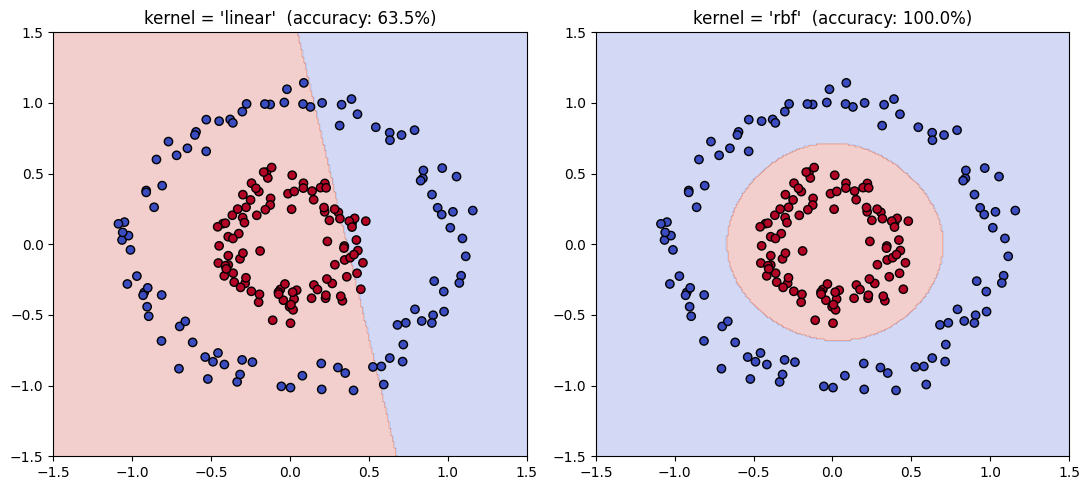

In [ ]:
# manufacture exactly the case a straight line can't handle: two rings
from sklearn.datasets import make_circles

ring_X, ring_y = make_circles(n_samples=200, factor=0.4, noise=0.08, random_state=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    m = SVCDemo(kernel=kernel, C=1.0, gamma="scale" if kernel == "rbf" else "auto")
    m.fit(ring_X, ring_y)
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(ring_X[:, 0], ring_X[:, 1], c=ring_y, cmap="coolwarm", edgecolors="k")
    ax.set_title(f"kernel = '{kernel}'  (accuracy: {m.score(ring_X, ring_y):.1%})")
plt.tight_layout()
plt.show()


The linear kernel does the best it can with a straight line and fails, because no straight line can separate a ring from its center. The rbf kernel bends the boundary to actually follow the ring. This is the concrete version of "why would I ever need a curved boundary" — some real relationships, including ones in medical or financial data, genuinely aren't linearly separable, and forcing a straight-line model onto them leaves accuracy on the table no amount of tuning `C` can recover.

### 9.1c The `C` hyperparameter — how strict is the margin allowed to be

Real data is rarely as clean as either demo above, some points usually land on the wrong side no matter where you draw the line. `C` controls how much the SVM is willing to tolerate that. A **large `C`** tells the model "barely tolerate any mistakes," producing a narrow margin that hugs the training data tightly, this is the SVM version of the deep, memorizing tree from Step 7, more prone to overfitting. A **small `C`** tells the model "a wider, more forgiving margin is fine even if a few points end up on the wrong side," trading a little training accuracy for a boundary that's more likely to generalize. This is the exact same bias-variance tradeoff Step 7 and Step 8's `learning_rate` sweep both made, now showing up a third time under a different name.

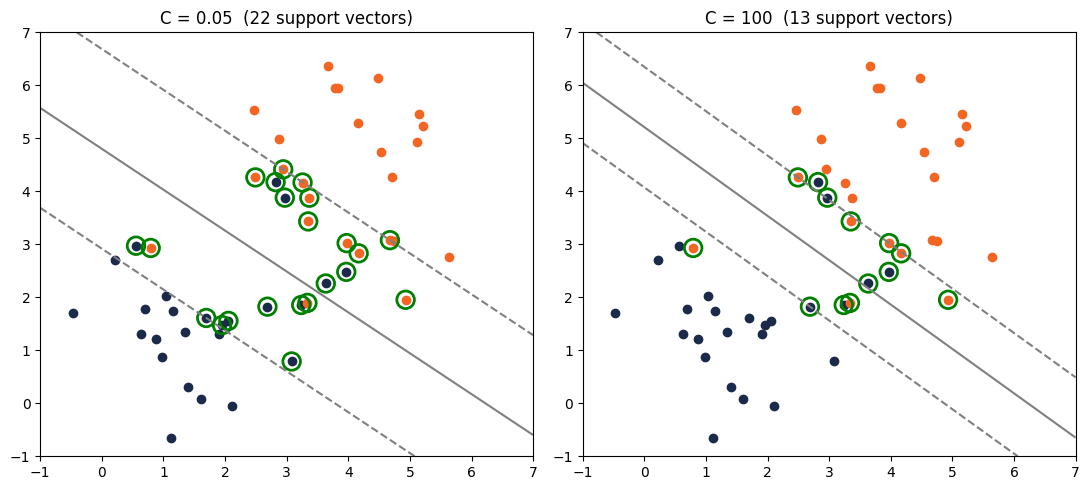

In [ ]:
# make the demo data slightly messier so C actually has something to react to
rng2 = np.random.RandomState(3)
messy_a = rng2.normal(loc=[2, 2], scale=1.1, size=(25, 2))
messy_b = rng2.normal(loc=[4, 4], scale=1.1, size=(25, 2))
messy_X = np.vstack([messy_a, messy_b])
messy_y = np.array([0]*25 + [1]*25)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c_val in zip(axes, [0.05, 100]):
    m = SVCDemo(kernel="linear", C=c_val)
    m.fit(messy_X, messy_y)
    xx, yy = np.meshgrid(np.linspace(-1, 7, 300), np.linspace(-1, 7, 300))
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="gray", linestyles=["--", "-", "--"])
    ax.scatter(messy_a[:, 0], messy_a[:, 1], color="#1B2A4A")
    ax.scatter(messy_b[:, 0], messy_b[:, 1], color="#F26522")
    ax.scatter(m.support_vectors_[:, 0], m.support_vectors_[:, 1], s=160, facecolors="none",
               edgecolors="green", linewidths=2)
    ax.set_title(f"C = {c_val}  ({m.n_support_.sum()} support vectors)")
plt.tight_layout()
plt.show()


Watch the margin width and the support-vector count change between the two panels, that's `C` acting directly on the tradeoff, made visible instead of just described. Fewer, tighter support vectors under a large `C` means the boundary is being pulled hard toward fitting every training point exactly. A wider margin under a small `C` means the model is deliberately leaving room to be right about patients it hasn't seen yet.

### 9.2 Now the real data

Diabetes doesn't separate this cleanly, real data never does, so instead of a hard line, sklearn's `SVC` finds the widest margin it can while tolerating some points landing on the wrong side. The `C` hyperparameter controls that tolerance: a large `C` punishes misclassified points heavily (narrow, strict margin, more prone to overfitting), a small `C` allows more slack for a wider, more forgiving margin. We standardized the features earlier today for logistic regression, SVMs need that same scaling, since margin distance is sensitive to features being on wildly different numeric scales (glucose in the hundreds, age in decades).

In [ ]:
# Step9a
svm = SVC(random_state=42, C=1.0, class_weight='balanced', kernel='linear')
svm.fit(X_train_scaled, y_train)
pred_svm = svm.predict(X_test_scaled)

accuracy_score(y_test, pred_svm)





0.6666666666666666

In [ ]:
precision_score(y_test, pred_svm)


0.09615384615384616

In [ ]:
f1_score(y_test, pred_svm)

0.16393442622950818

In [ ]:
recall_score(y_test, pred_svm)

0.5555555555555556

### 9.3a Tuning it properly instead of guessing `C` and the kernel

We picked `kernel="linear"` and `C=1.0` above by hand. The right way, same as every tuning decision today and , is to let cross-validation search a real grid instead. `gamma` is the rbf kernel's own hyperparameter, it controls how far a single training point's influence reaches: a **large `gamma`** means each point only affects its immediate neighborhood (a tightly wiggly, easily overfit boundary), a **small `gamma`** means each point's influence reaches further (a smoother, simpler boundary). Same overfitting story as `C`, just controlling a different part of the shape.

In [ ]:
# Step9c
from sklearn.model_selection import GridSearchCV

svm_param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
}

svm_grid = GridSearchCV(SVC(class_weight="balanced", random_state=42), svm_param_grid, cv=5)
svm_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best cross-validated accuracy: {svm_grid.best_score_:.1%}")

svm_tuned = svm_grid.best_estimator_
pred_svm_tuned = svm_tuned.predict(X_test_scaled)

print(f"\nTest accuracy:  {accuracy_score(y_test, pred_svm_tuned):.1%}")
print(f"Test precision: {precision_score(y_test, pred_svm_tuned):.1%}")
print(f"Test recall:    {recall_score(y_test, pred_svm_tuned):.1%}")
print(f"Test F1:        {f1_score(y_test, pred_svm_tuned):.1%}")


Compare `svm_grid.best_params_` against the hand-picked `kernel="linear", C=1.0` we started with. If cross-validation picked something different, that's the same lesson Step 8's tuning gave us with tree depth and learning rate: your first reasonable-sounding guess at a hyperparameter is rarely the best one, and the only honest way to find the better one is to actually search and validate, not to eyeball it.

In [ ]:
# Step9d — add the tuned SVM to the scoreboard as its own row
comparison.loc[len(comparison)] = ["SVM (tuned)", accuracy_score(y_test, pred_svm_tuned),
                                     precision_score(y_test, pred_svm_tuned), recall_score(y_test, pred_svm_tuned), f1_score(y_test, pred_svm_tuned)]
comparison


### 9.3 When do you actually reach for an SVM instead of a tree or a forest?

SVMs tend to earn their keep when the classes are genuinely separable by some kind of boundary, even a curved one (a `kernel="rbf"` swaps the straight-line boundary for a curved one, without you having to hand-engineer curved features), and especially when you have many features relative to how many rows you have, a setting where trees can struggle to find reliable splits but a margin-based boundary can still hold up. What you give up is exactly what a tree gives you for free: an SVM's boundary isn't something you can read off as a flowchart, `svm.coef_` for a linear kernel is a set of weights, not a set of readable questions, so if explainability to a non-technical audience matters as much as accuracy, that's a real point in the tree/forest family's favor, not the SVM's.

In [ ]:
# CodeGrade step9b
comparison.loc[len(comparison)] = ["SVM (linear, balanced)", accuracy_score(y_test, pred_svm),
                                     precision_score(y_test, pred_svm), recall_score(y_test, pred_svm), f1_score(y_test, pred_svm)]
comparison.style.format({"Accuracy": "{:.1%}", "Precision": "{:.1%}", "Recall": "{:.1%}", "F1": "{:.1%}"})


---
## Wrap-up: everything we've built today, side by side

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metrics_names))
n_models = len(comparison)
w = 0.8 / n_models
for i, row in comparison.iterrows():
    ax.bar(x + (i - (n_models - 1) / 2) * w, [row["Accuracy"], row["Precision"], row["Recall"], row["F1"]],
           width=w, label=row["Model"])
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1)
ax.set_title("Every model built today and , same test patients")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


Read this chart against the one question that's run underneath every model since : which of these actually catches diabetic patients, not just which one has the highest accuracy? Compare the recall bars specifically, that's the column your original scenario, minimizing missed diagnoses, cares about most, and it's the column plain accuracy has been hiding from us all day.

**What we covered tonight:** random forests, building many independent trees on resampled data and letting them vote, trading a bit of interpretability for real stability; boosting, building trees sequentially so each one corrects the last, and the learning-rate/n_estimators tradeoff that controls how aggressively it does that; and support vector machines, an entirely different approach that draws the widest possible boundary between classes instead of asking a sequence of yes/no questions at all.

Tuesday: the full project workflow, a proper pipeline that chains preprocessing and model selection together, run across everything we've built this week, to choose a final model the right way instead of by eyeballing one table.